# Сборный проект - 2

## Задача 1

 HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.
 
 
Компания предоставила данные с характеристиками сотрудников компании. Среди них — **уровень удовлетворённости сотрудника работой в компании.** Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, **где 0 — совершенно неудовлетворён**, **1 — полностью удовлетворён.**

Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли.

**Задачи:**
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.
   **Почему бизнесу это важно:** удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.
2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**План работы:**

**1. Загрузка и первичный осмотр данных**

- Открытие и проверка корректности загрузки.

- Проверка на пропуски, аномалии и ошибки в данных.

**2. Предобработка данных**

- Заполнение пропущенных значений.

- Исправление опечаток и приведение столбцов к корректным типам.

- Проверка и сортировка по идентификаторам.

**4. Исследовательский анализ данных (EDA)**

- Изучение распределений признаков.

- Анализ портрета уволившихся сотрудников.

- Проверка гипотез о влиянии удовлетворённости на отток.

**5. Корреляционный анализ**

- Выявление взаимосвязей между признаками.

- Проверка на мультиколлинеарность.

**6. Подготовка признаков**

- Выделение категориальных и числовых признаков.

- Настройка пайплайнов кодирования и масштабирования.

- Создание общего препроцессора данных.

**7. Обучение моделей**

- Подбор и обучение моделей регрессии и классификации.

- Настройка гиперпараметров.

- Выбор лучшей модели по метрикам: SMAPE и ROC-AUC.

**8. Анализ важности признаков**

- Интерпретация моделей.

- Выявление факторов, влияющих на удовлетворённость и увольнение.

## Установка библиотек 

In [1]:
#установление модуля phik, который используется для вычисления корреляции между категориальными и числовыми переменными
#особенно когда данные содержат нелинейные зависимости.
!pip install phik -q
!pip install imbalanced-learn -q
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy import stats as st

from sklearn.dummy import DummyRegressor, DummyClassifier
from phik.report import plot_correlation_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split,  RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor, plot_tree,  DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, make_scorer, mean_squared_error, r2_score, accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE=42

## Загрузка данных

### Таблица train_job_satisfaction_rate - Тренировочная выборка

In [3]:
train_job_satisfaction_rate = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
print('Размерность таблицы:')
print(train_job_satisfaction_rate.shape)
print()
print("Общая информация о таблице:")
train_job_satisfaction_rate.info()
train_job_satisfaction_rate.head()

Размерность таблицы:
(4000, 10)

Общая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


### Таблица test_features - Входные признаки тестовой выборки

In [4]:
test_features = pd.read_csv('/datasets/test_features.csv')
print('Размерность таблицы:')
print(test_features.shape)
print()
print("Общая информация о таблице:")
test_features.info()
test_features.head()

Размерность таблицы:
(2000, 9)

Общая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


### Таблица test_target_job_satisfaction_rate - Целевой признак тестовой выборки

In [5]:
test_target_job_satisfaction_rate = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')
print('Размерность таблицы:')
print(test_target_job_satisfaction_rate.shape)
print()
print("Общая информация о таблице:")
test_target_job_satisfaction_rate.info()
test_target_job_satisfaction_rate.head()

Размерность таблицы:
(2000, 2)

Общая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Загрузка данных**

Загрузка данных и открытие файлов прошли успешно. В таблицах "train_job_satisfaction_rate" и "test_features" - обнаружены пропуски, которые заполним на этапе пайплайнов.

## Предобработка данных 

### Проверка на дубликаты: явные/ неявные.

In [6]:
print('Количество явных дубликатов в train_job_satisfaction_rate: ',train_job_satisfaction_rate.duplicated().sum()) #убедимся, что нет дубликатов
print('Количество явных дубликатов в test_features: ',test_features.duplicated().sum())
print('Количество явных дубликатов в test_target_job_satisfaction_rate: ',test_target_job_satisfaction_rate.duplicated().sum())


Количество явных дубликатов в train_job_satisfaction_rate:  0
Количество явных дубликатов в test_features:  0
Количество явных дубликатов в test_target_job_satisfaction_rate:  0


Явные дубликаты отсутствуют.

Далее проведем проверку на неявные дубликаты: 

1. Рассмотрим все уникальные значения столбцов типа "object".
2. Избавимся от неявных дубликатов.
3. Повтор проверки на явные дубликаты.

In [7]:
print("Уникальные названия в таблице train_job_satisfaction_rate:")
print()
print ('Отдел, в котором работает сотрудник:', set(train_job_satisfaction_rate['dept'].unique()))
print ('Уровень загруженности сотрудника:', set(train_job_satisfaction_rate['workload'].unique()))
print ('Уровень занимаемой должности:', set(train_job_satisfaction_rate['level'].unique()))
print ('Было ли повышение за последний год:', set(train_job_satisfaction_rate['last_year_promo'].unique()))
print ('Нарушал ли сотрудник трудовой договор за последний год:', set(train_job_satisfaction_rate['last_year_violations'].unique()))

Уникальные названия в таблице train_job_satisfaction_rate:

Отдел, в котором работает сотрудник: {nan, 'technology', 'purchasing', 'sales', 'hr', 'marketing'}
Уровень загруженности сотрудника: {'high', 'low', 'medium'}
Уровень занимаемой должности: {nan, 'junior', 'sinior', 'middle'}
Было ли повышение за последний год: {'yes', 'no'}
Нарушал ли сотрудник трудовой договор за последний год: {'yes', 'no'}


<div style="border: 2px solid black; padding: 10px; border-radius: 5px;">
    
**Опечатка:**
    
Уровень занимаемой должности: {nan, 'sinior', 'middle', 'junior'} - перезапишем "sinior" на "senior".

</div>

In [8]:
#перезапись
train_job_satisfaction_rate.loc[train_job_satisfaction_rate['level'] == 'sinior','level'] = 'senior'
print ('Уровень занимаемой должности:', set(train_job_satisfaction_rate['level'].unique()))

Уровень занимаемой должности: {'senior', 'junior', 'middle', nan}


In [9]:
print("Уникальные названия в таблице test_features:")
print()
print ('Отдел, в котором работает сотрудник:', set(test_features['dept'].unique()))
print ('Уровень загруженности сотрудника:', set(test_features['workload'].unique()))
print ('Уровень занимаемой должности:', set(test_features['level'].unique()))
print ('Было ли повышение за последний год:', set(test_features['last_year_promo'].unique()))
print ('Нарушал ли сотрудник трудовой договор за последний год:', set(test_features['last_year_violations'].unique()))

Уникальные названия в таблице test_features:

Отдел, в котором работает сотрудник: {nan, ' ', 'hr', 'technology', 'purchasing', 'sales', 'marketing'}
Уровень загруженности сотрудника: {'high', ' ', 'low', 'medium'}
Уровень занимаемой должности: {nan, 'junior', 'sinior', 'middle'}
Было ли повышение за последний год: {'yes', 'no'}
Нарушал ли сотрудник трудовой договор за последний год: {'yes', 'no'}


<div style="border: 2px solid black; padding: 10px; border-radius: 5px;">
    
**Опечатка:**
    
Уровень занимаемой должности: {nan, 'sinior', 'middle', 'junior'} - перезапишем "sinior" на "senior".

</div>

In [10]:
#перезапись
test_features.loc[test_features['level'] == 'sinior','level'] = 'senior'
print ('Уровень занимаемой должности:', set(test_features['level'].unique()))

Уровень занимаемой должности: {'senior', 'junior', 'middle', nan}


<div style="border: 2px solid black; padding: 10px; border-radius: 5px;">
    
**Пропуски:**
    
Обнаружены пропущенные значения, помимо Nan, о которых мы знали ранее. Выведем те строки, в которых пропуски и заполним их наиболее часто встречающимся значением.
</div>

In [11]:
#вывожу строку с пропуском
test_features[test_features['dept'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
1699,822186,,middle,medium,3,no,no,4,38400


In [12]:
test_features[test_features['workload'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
15,590867,marketing,junior,,4,no,no,4,28800


In [13]:
mode_dept = train_job_satisfaction_rate['dept'].replace(['', ' '], np.nan).mode()[0]
mode_workload = train_job_satisfaction_rate['workload'].replace(['', ' '], np.nan).mode()[0]

test_features['dept'] = test_features['dept'].replace(['', ' '], np.nan).fillna(mode_dept)
test_features['workload'] = test_features['workload'].replace(['', ' '], np.nan).fillna(mode_workload)

print ('Отдел, в котором работает сотрудник:', set(test_features['dept'].unique()))
print ('Уровень загруженности сотрудника:', set(test_features['workload'].unique()))

Отдел, в котором работает сотрудник: {'hr', 'technology', 'purchasing', 'sales', 'marketing'}
Уровень загруженности сотрудника: {'high', 'low', 'medium'}


### Сортировка по id для тестовых выборок

In [14]:
test_features = test_features.sort_values(by='id').reset_index(drop=True)
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,100298,hr,junior,low,2,no,no,4,19200
1,100480,marketing,junior,low,4,no,no,4,16800
2,100503,purchasing,middle,high,5,no,no,4,55200
3,100610,sales,middle,medium,5,no,no,4,43200
4,100692,sales,middle,high,6,no,no,4,48000


In [15]:
test_target_job_satisfaction_rate = test_target_job_satisfaction_rate.sort_values(by='id').reset_index(drop=True)
test_target_job_satisfaction_rate.head()

,id,job_satisfaction_rate
0,100298,0.80
1,100480,0.84
2,100503,0.79
3,100610,0.75
4,100692,0.69


<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Предобработка данных**

Были выявленны пропуски, помимо уже известных нам "Nan", они находились в столбцах 'dept' и 'workload', по 1 пропуску в каждом. Пропуски были заполнены, наиболее часто встречающимся значением в столбце: 'dept' - 'sales, 'workload' - 'medium'.
    
Также была исправлена опечатка в таблицах - Уровень занимаемой должности: {nan, 'sinior', 'middle', 'junior'} - перезаписали "sinior" на "senior".
    
Названия столбцов написаны в корректном стиле - вмешательства не требуют.

Все данные приведены к корректному типу - вмешательства не требуют.
    
Тестовые выборки отсортированны по id.

## Исследовательский анализ данных

### Функции для гистограмм/столбчатых диаграмм/боксплотов

In [16]:
#столбчатые диаграммы для дискретных признаков
def barplot_features(df, features):
    for col in features:
        plt.figure(figsize=(15, 6))

        # Barplot
        plt.subplot(1, 2, 1)
        sns.countplot(x=df[col], color='#90CAF9')
        plt.title(f'Barplot: {col}')
        plt.xlabel('Значение')
        plt.ylabel('Количество')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col], color='#90CAF9')
        plt.title

In [17]:
#гистограммы для непрерывных признаков
def histplot_features(df, features):
    for col in features:

        plt.figure(figsize=(15, 6))

        # Гистограмма с KDE
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, bins=30, color='#948AD6')
        plt.title(f'Гистограмма: {col}')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col], color='#948AD6')
        plt.title(f'Боксплот: {col}')

        plt.tight_layout()
        plt.show()

In [18]:
#диаграммы для категориальных признаков
def plot_categorical_features(df, features):
    for col in features:
        plt.figure(figsize=(8, 4))
        ax = sns.countplot(x=df[col], palette='pastel')
        sns.countplot(x=df[col], palette='pastel')
        plt.title(f'Распределение: {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45)
        
        # Добавляем подписи с процентами
        total = len(df)
        for p in ax.patches:
            count = p.get_height()
            percent = 100 * count / total
            ax.annotate(f'{percent:.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()

### Таблица train_job_satisfaction_rate

In [19]:
numeric_features_1 = ['employment_years', 'supervisor_evaluation'] #дискретные количественные признаки
numeric_features_2= ['salary', 'job_satisfaction_rate'] #непрерывные количественные признаки
object_features = train_job_satisfaction_rate.select_dtypes(include=['object']).columns #категориальные признаки

In [20]:
train_job_satisfaction_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


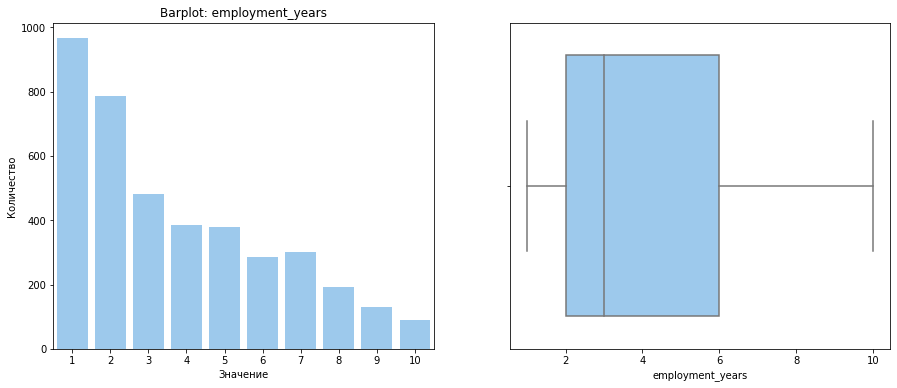

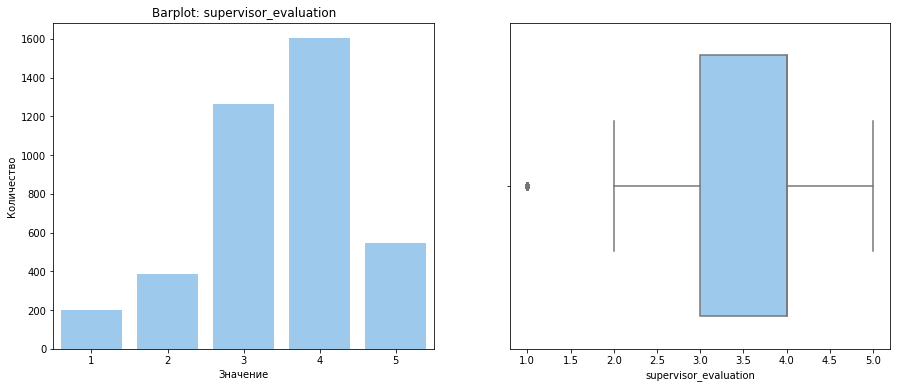

In [21]:
barplot_features(train_job_satisfaction_rate, numeric_features_1)

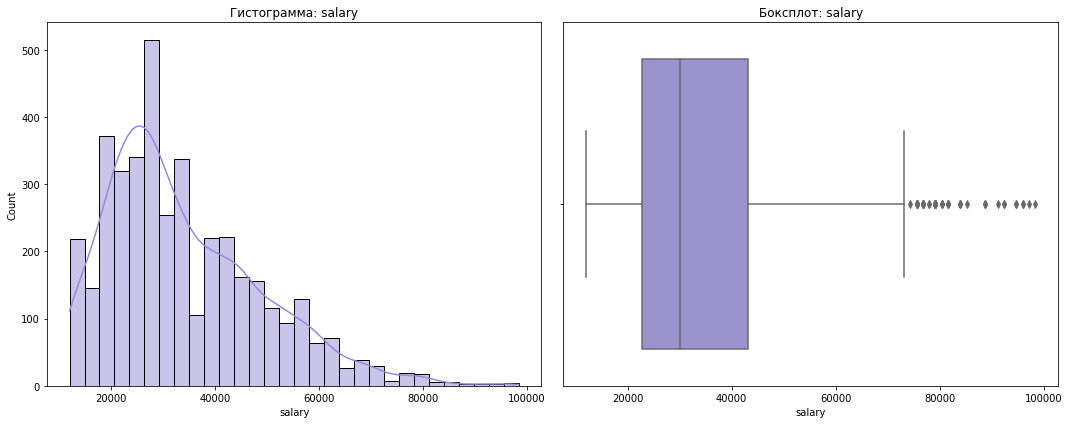

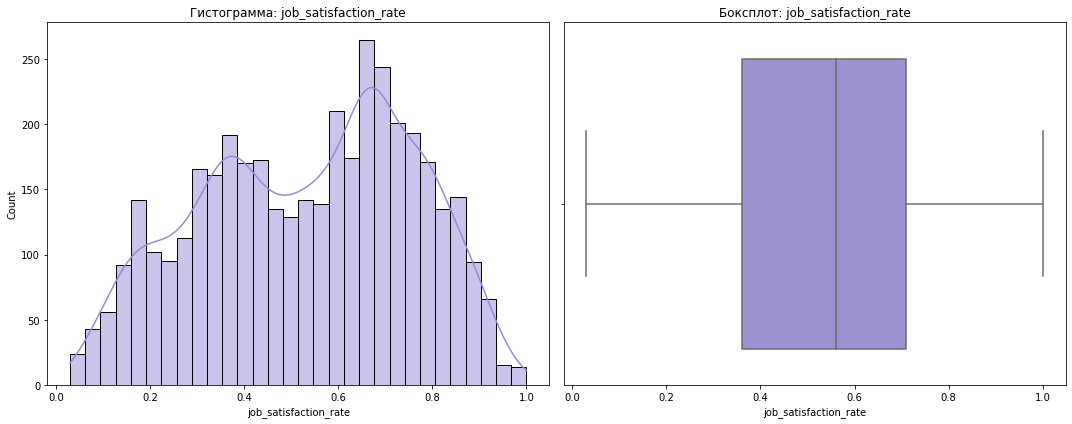

In [22]:
histplot_features(train_job_satisfaction_rate, numeric_features_2)

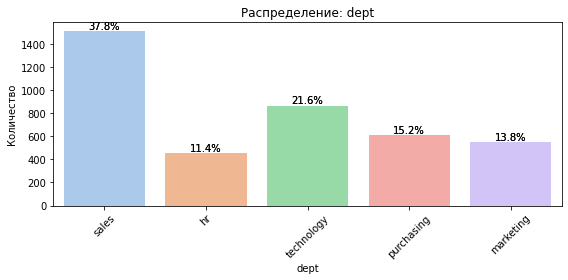

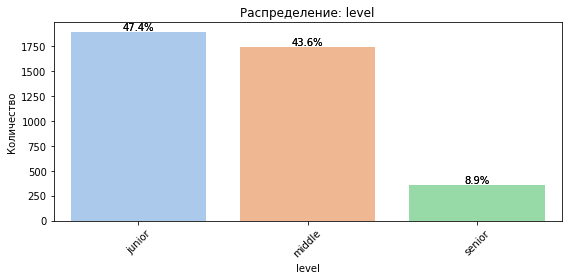

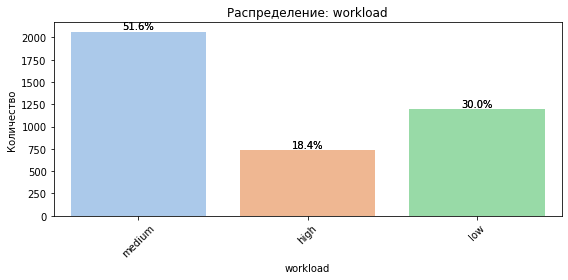

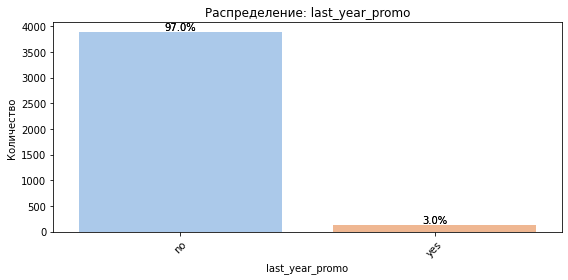

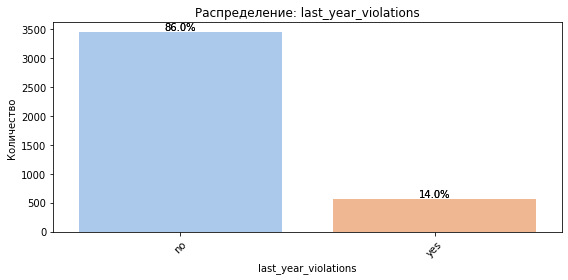

In [23]:
plot_categorical_features(train_job_satisfaction_rate, object_features )

<div style="background-color:#F7F7F7; padding:10px; border-radius:10px; color:#333;">


1. **employment_years — длительность работы в компании (в годах):** 

   Большинство сотрудников, работают в компании 1 год.
   
   В среднем сотрудники работают в компании около 3-х с половиной лет.
    
    
2. **supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель:** 

   Большинство сотрудников получили оценку от руководителя - 4, однако так же достатчно много сотрудников получили оценку 3.
   
   Средняя оценка сотруников по компании составляет 3.47.


3. **salary — ежемесячная зарплата сотрудника:**

   Средняя ежемесячная зарплата сотрудников 33926, диаппазон зарплаты варьируется от 22800 до 43200.
   
   Присутствуют сотрудники с оплатой в 98400, но таких сотрудников мало. Таких сотрудников можно увидеть по боксплоту, как выбросы.
   
   
4. **job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак:**

   Большинство сотрудников оценивают удовлетворенность работой в компании от 0.36 до 0.71.
   
   Средняя оценка удовлетворенности работой - 0.53.


5. **dept — отдел, в котором работает сотрудник:**

    Большая часть сотрудников работают в отделе sales - 37.8%.
    
    Следом идут:
    - technology - 21.6%
    - purchasing - 15.2%
    - marketing - 13.8%
    - hr - 11.4%
   
6. **level — уровень занимаемой должности:**

   - junior - 47.4%
   - middle - 43.6%
   - senior - 8.9%
   
7. **workload — уровень загруженности сотрудника:**

   Основная часть сотрудников 51.6% со среднем уровнем загруженности.
   
8. **last_year_promo — показывает, было ли повышение за последний год:**

   97% сотрудников не получила повышения за последний год.
   
   
9. **last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год:**

   86% сотрудников не нарушали трудовой договор за последний год.

### Таблица test_features

In [24]:
test_features.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [25]:
test_numeric_features_1 = ['employment_years', 'supervisor_evaluation'] #дискретные количественные признаки
test_numeric_features_2= ['salary'] #непрерывные количественные признаки
test_object_features = test_features.select_dtypes(include=['object']).columns #категориальные признаки

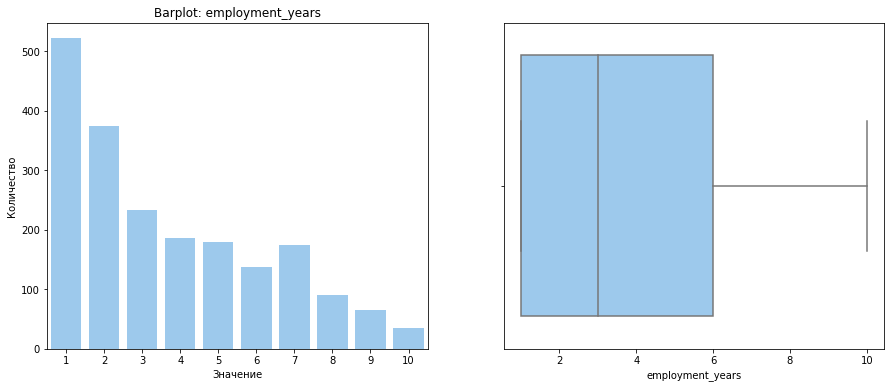

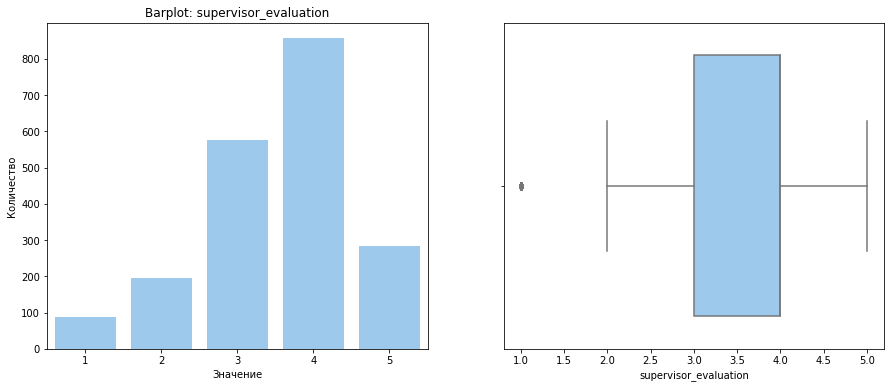

In [26]:
barplot_features(test_features, test_numeric_features_1)

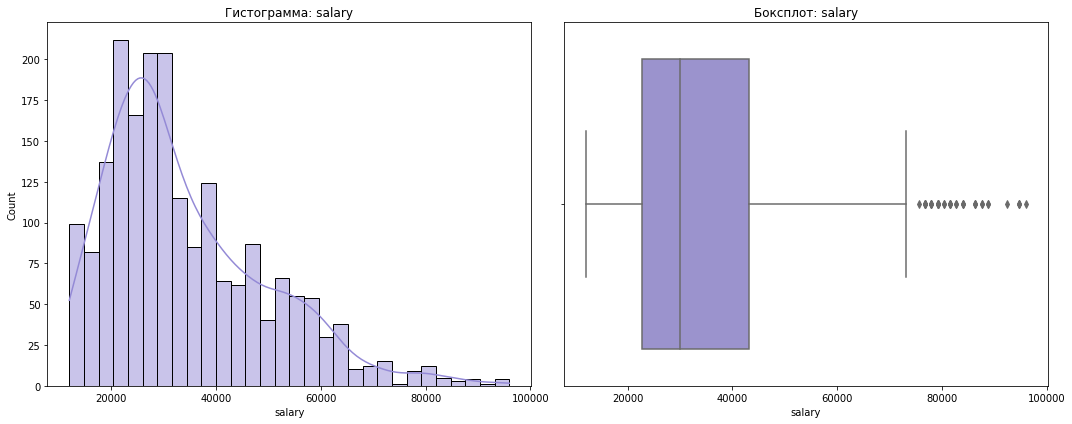

In [27]:
histplot_features(test_features, test_numeric_features_2)

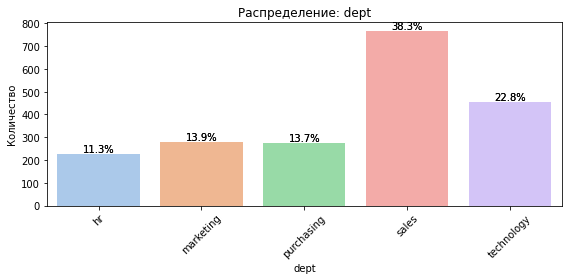

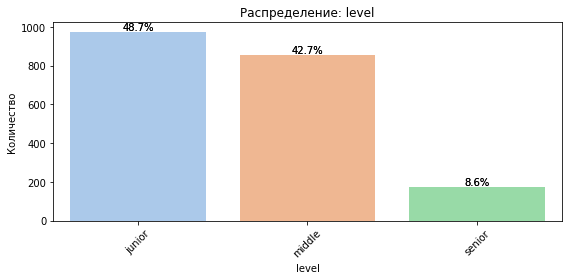

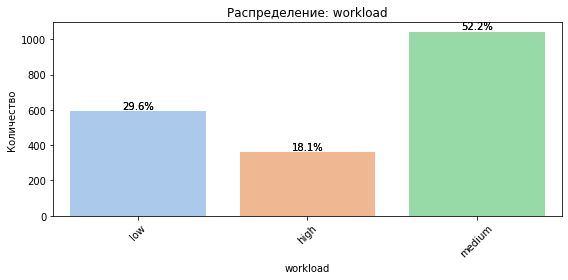

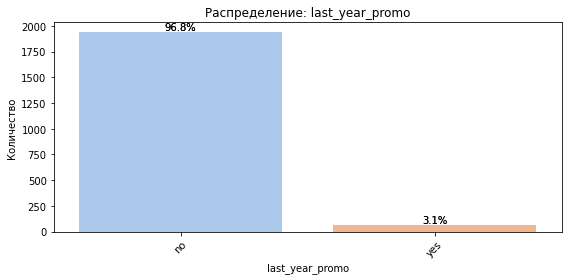

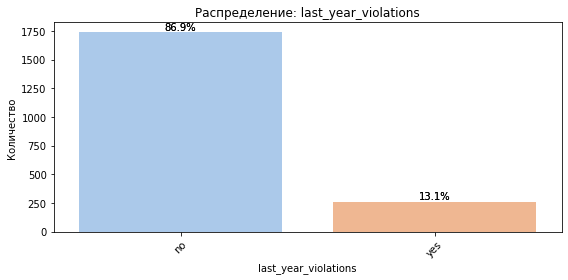

In [28]:
plot_categorical_features(test_features, test_object_features )

### Таблица test_target_job_satisfaction_rate

In [29]:
test_target_job_satisfaction_rate.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


In [30]:
numeric_features_3= ['job_satisfaction_rate'] #непрерывные количественные признаки

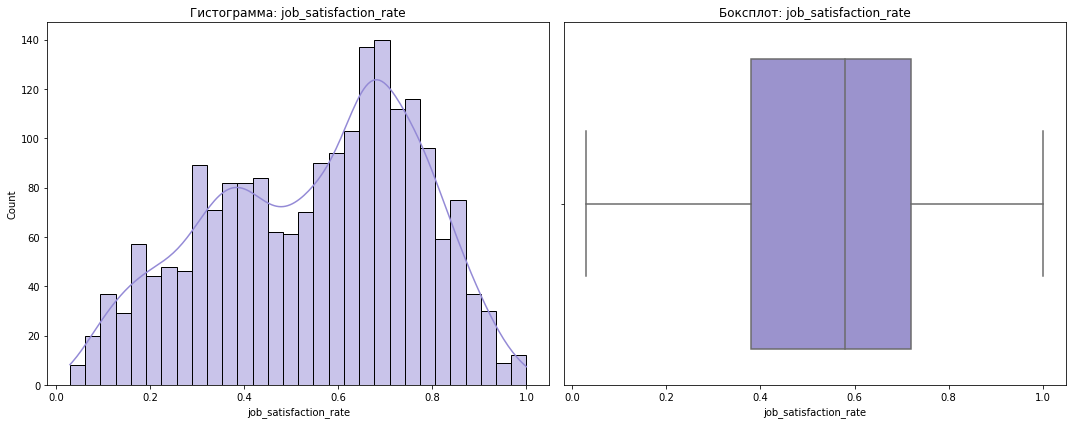

In [31]:
histplot_features(test_target_job_satisfaction_rate, numeric_features_3)

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Исследовательский анализ данных**

1. **Стаж работы:** большинство сотрудников работают в компании 1 год, в среднем около 3.5 лет.

2. **Оценка руководителя:** чаще всего ставится оценка 4, средняя 3.47.

3. **Зарплата:** средняя — 33 926 ₽; большинство получают от 22 800 до 43 200 ₽. Зарплаты выше 98 400 ₽ - редкие выбросы.

4. **Удовлетворённость работой:** чаще всего в диапазоне от 0.36 до 0.71, средняя  0.53.

5. **Отделы:** больше всего сотрудников в отделе продаж (sales - 37.8%), далее  technology, purchasing, marketing и HR.

6. **Уровень должности:** преобладают junior (47.4%) и middle (43.6%) специалисты.

7. **Загруженность:** более половины сотрудников (51.6%) имеют среднюю загруженность.

8. **Повышения:** 97% сотрудников не получали повышения за последний год.

9. **Нарушения:** 86% сотрудников не нарушали трудовой договор в прошлом году.   
    
    
Данные из тренировочной выборки и из тестовых схожи.

## Корреляционный анализ

In [32]:
#удалим id покупателя, так как он не несет никакой смыловой информации.
train_job_satisfaction_rate = train_job_satisfaction_rate.drop('id', axis=1)

In [33]:
print('Количество явных дубликатов в train_job_satisfaction_rate: ',train_job_satisfaction_rate.duplicated().sum())

Количество явных дубликатов в train_job_satisfaction_rate:  245


In [34]:
train_job_satisfaction_rate = train_job_satisfaction_rate.drop_duplicates() 
print('Количество явных дубликатов в train_job_satisfaction_rate: ',train_job_satisfaction_rate.duplicated().sum())

Количество явных дубликатов в train_job_satisfaction_rate:  0


In [35]:
#выберем все непрерывные признаки
interval_cols = numeric_features_2
phik_overview = train_job_satisfaction_rate.phik_matrix(interval_cols=interval_cols)

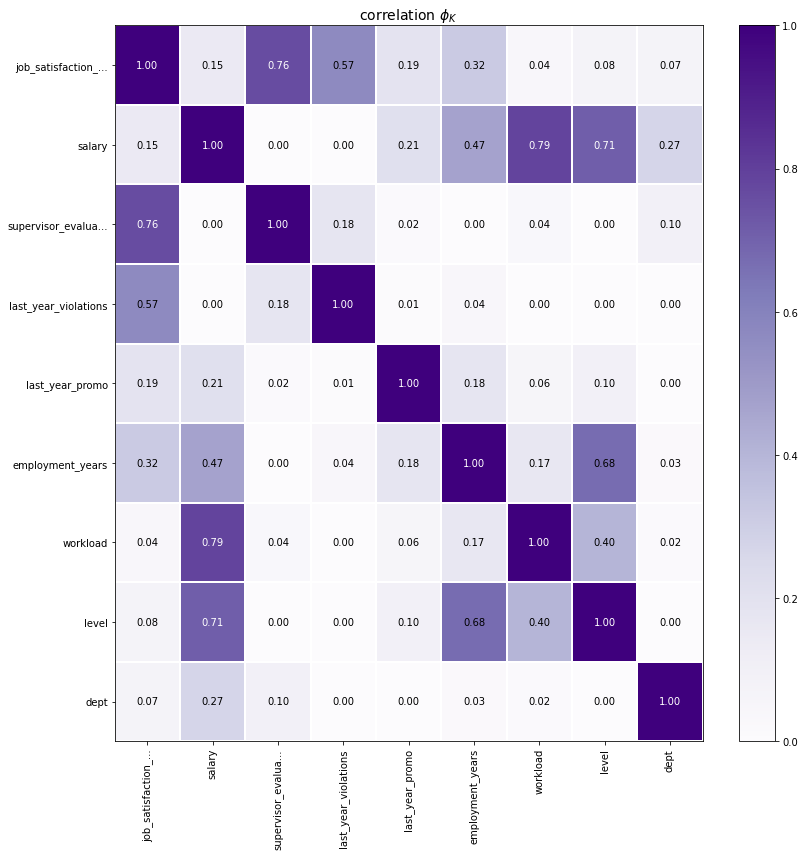

In [36]:
plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="Purples", 
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1, 
                        figsize=(12, 12))
plt.tight_layout()

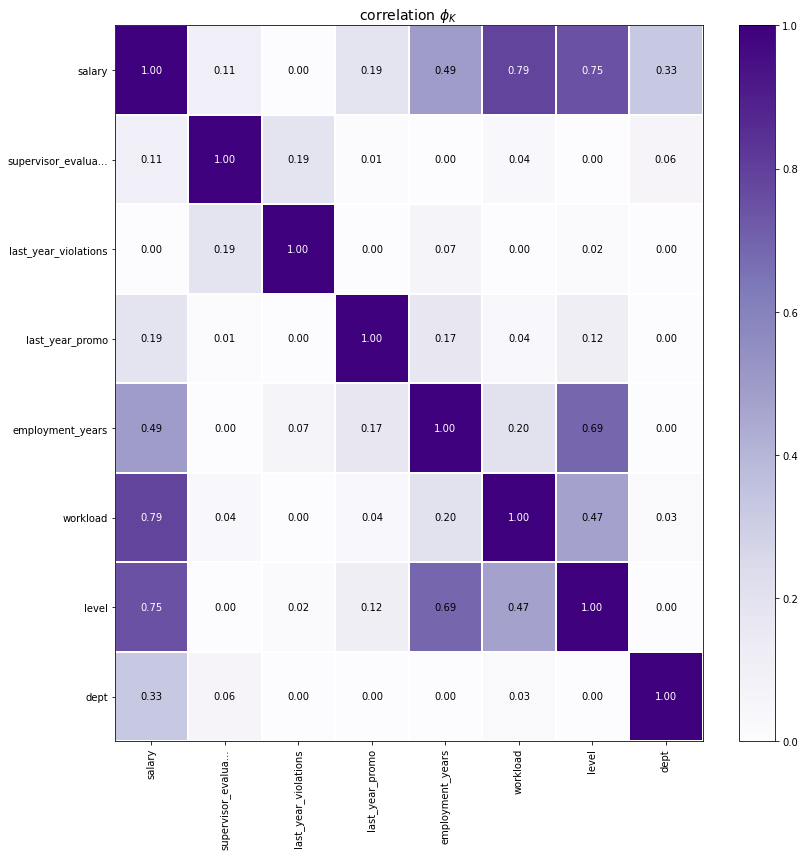

In [37]:
#удалим id покупателя, так как он не несет никакой смыловой информации.
test_features = test_features.drop('id', axis=1)

#выберем все непрерывные признаки
interval_cols = test_numeric_features_2
phik_overview = test_features.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="Purples", 
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1, 
                        figsize=(12, 12))
plt.tight_layout()

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Корреляционный анализ**

Есть неплохая корреляция между:

1. job_satisfaction_rate и supervisor_evaluation - 0.73
2. job_satisfaction_rate и last_year_violations - 0.59
3. workload и salary - 0.89
4. level и salary - 0.84
5. level и employment_years - 0.68

Для мультиколлинеарности нужна корреляция 0.85 и выше, такая корреляция не присутствует.

##  Подготовка данных

Целевой признак непрерывный, следовательно перед нами задача регрессии, поэтому будем использовать модели: DecisionTreeRegressor и LinearRegression

In [38]:
train_data = train_job_satisfaction_rate.copy()

In [39]:
# создание собственной метрики для оценки модели

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    smape_values = np.where(denominator == 0, 0, numerator / denominator)
    return 100 * np.mean(smape_values)

SMAPE_score = make_scorer(smape, greater_is_better=False)

In [40]:
#признаки для OridinalEncoder
ord_columns = ['level', 'workload']

#признаки для OneHotEncoder
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']

#признаки для масштабирования
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

In [41]:
# создание тренировочной выборки входных признаков и целевого признака
X_train = train_data.drop('job_satisfaction_rate', axis=1)

In [42]:
y_train = train_data['job_satisfaction_rate']


X_test = test_features
y_test = test_target_job_satisfaction_rate['job_satisfaction_rate']

In [43]:
print("Тренировочная выборка входные значения: ", X_train.shape )
print("Тренировочная выборка целевое значение: ", y_train.shape )
print("Тестовая выборка входные значения : ", X_test.shape)
print("Тестовая выборка целевое значение: ", y_test.shape)

Тренировочная выборка входные значения:  (3755, 8)
Тренировочная выборка целевое значение:  (3755,)
Тестовая выборка входные значения :  (2000, 8)
Тестовая выборка целевое значение:  (2000,)


In [44]:
# OHE pipeline
ohe_pipe = Pipeline([
    ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Ordinal pipeline
ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        categories=[
            ['junior', 'middle', 'senior'],
            ['low', 'medium', 'high']
        ],
        handle_unknown='use_encoded_value', unknown_value=-1
    )),
    ('simpleImputer_after_ord', SimpleImputer(strategy='most_frequent'))
])

# Общий препроцессор
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_columns),
    ('ord', ord_pipe, ord_columns),
    ('num', StandardScaler(), num_columns)
], remainder='passthrough')

# Финальный пайплайн
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

param_distributions = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 21),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }, 
] 

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Подготовка данных**

1. Создана пользовательская метрика SMAPE «симметричное среднее абсолютное процентное отклонение» для оценки моделей регрессии, с учетом симметричного относительного отклонения.

2. Определены группы признаков для разных типов обработки:

 - ord_columns — категориальные признаки с порядком (для OrdinalEncoder).

 - ohe_columns — категориальные признаки без порядка (для OneHotEncoder).

 - num_columns — числовые признаки, подлежащие масштабированию.

3. Разделение данных:

 - Обучающая выборка: 4000 объектов.

 - Тестовая выборка: 2000 объектов.

4. Сконструированы пайплайны предобработки:

 - ohe_pipe — кодирование категориальных признаков через OneHotEncoder.

 - ord_pipe — обработка упорядоченных категориальных признаков с последующей иммутацией.

 - num — масштабирование числовых признаков с помощью StandardScaler.

5. Собран общий препроцессор (ColumnTransformer), объединяющий все этапы обработки данных.

6. Создан финальный пайплайн (pipe_final).

7. Определено пространство гиперпараметров (param_distributions) для подбора:

8. Модели: DecisionTreeRegressor и LinearRegression.

9. Варианты обработки числовых признаков: StandardScaler, MinMaxScaler и passthrough

## Обучение моделей

In [45]:
# рандомизированный перебор гиперпараметров
random_search = RandomizedSearchCV(
    estimator=pipe_final,
    param_distributions=param_distributions,
    n_iter=30,  
    cv=5,
    scoring=SMAPE_score,
    n_jobs=-1,
    random_state=42  
)

# обучение модели
random_search.fit(X_train, y_train);

In [46]:
best_smape = -random_search.best_score_

print(f"Метрика SMAPE для лучшей модели: {best_smape:.2f}")
print("Лучшая модель и её параметры:\n")
print(random_search.best_params_)

Метрика SMAPE для лучшей модели: 15.71
Лучшая модель и её параметры:

{'preprocessor__num': MinMaxScaler(), 'models__max_depth': 13, 'models': DecisionTreeRegressor(random_state=42)}


In [47]:
print(f'Метрика SMAPE на тестовой выборке: {round(smape(y_test, random_search.predict(X_test)), 2)}')

Метрика SMAPE на тестовой выборке: 14.43


In [48]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)  # X_train — твои признаки для модели job_satisfaction_rate

# Предсказания
dummy_preds = dummy.predict(X_test)
model_preds = random_search.predict(X_test)

# Сравнение
print("DummyRegressor:")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, dummy_preds)), 3))
print("R2:", round(r2_score(y_test, dummy_preds), 3))

print("\n Модель:")
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, model_preds)), 3))
print("R2:", round(r2_score(y_test, model_preds), 3))

DummyRegressor:
RMSE: 0.221
R2: -0.005

 Модель:
RMSE: 0.081
R2: 0.866


<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Обучение моделей**

Модели обучены, найдела лучшая модель и это: DecisionTreeRegressor(random_state=42), 'models__max_depth': 13, 'preprocessor__num': MinMaxScaler()
    
**Критерий успеха: SMAPE ≤ 15 на тестовой выборке:**
    
На тестовой выборке метрика SMAPE, показала хороший результат - 14.28.
    
**Проверка на адекватность лучшей модели, показала:**
    
- RMSE: 0.081 - предсказания в среднем сильно ближе к реальности, ошибка почти в 3 раза меньше, чем у Dummy.

- R²: 0.866 - 86.6% дисперсии объясняется моделью, что говорит о высоком качестве предсказаний.

## Промежуточные выводы

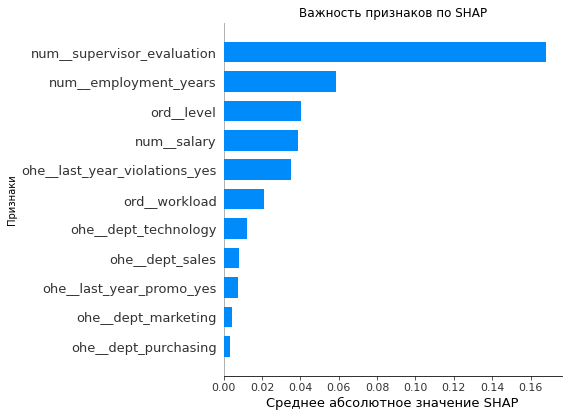

In [49]:
best_model = random_search.best_estimator_
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["models"]

# 2. Преобразование данных
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# 3. SHAP с TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

# 4. График важности признаков
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=20, show=False)

plt.title("Важность признаков по SHAP")
plt.xlabel("Среднее абсолютное значение SHAP")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

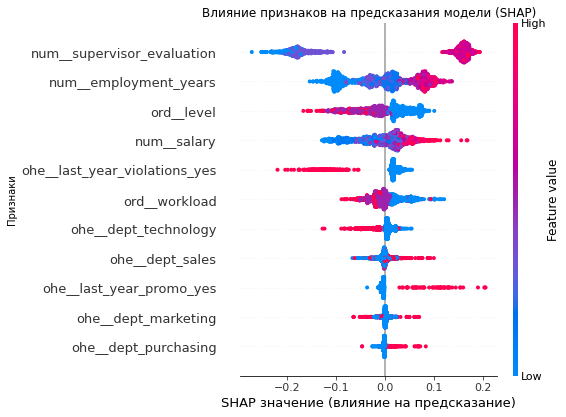

In [50]:
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, max_display=20, show=False)

plt.title("Влияние признаков на предсказания модели (SHAP)")
plt.xlabel("SHAP значение (влияние на предсказание)")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Промежуточные выводы**

Удовлетворенность сотрудников сильнее всего зависит от:

1. оценки от руководителя

2. длительности работы в компании

3. уровня должности

4. факт нарушений 

5. загруженность

Зарплата влияет, но не так значительно, как можно было ожидать. 
    
    
**num__supervisor_evaluation:**

1. Высокие оценки от руководителя повышают предсказанное значение удовлетворенности.

2. Низкие оценки — понижают.

**num__employment_years:**

1. Длительный стаж в компании чаще ассоциируется с высокой удовлетворенностью.

2. Малый стаж — с пониженной.

**ord__level:**

1. Senior - тянут предсказание вверх.

2. Junior — вниз.

**num__salary:**

Более высокая зарплата слегка повышает предсказание, но влияние не такое сильное, как у предыдущих факторов.

**ohe__last_year_violations_yes:**

Сотрудники с нарушениями склонны к снижению удовлетворённости.

**ord__workload:**

1. Высокая загруженность снижает предсказание.

2. Средняя/низкая — чаще повышает.

## Задача 2:  Предсказание увольнения сотрудника из компании

### Таблица train_quit

In [51]:
train_quit = pd.read_csv('/datasets/train_quit.csv')
print('Размерность таблицы:')
print(train_quit.shape)
print()
print("Общая информация о таблице:")
train_quit.info()
train_quit.head()

Размерность таблицы:
(4000, 10)

Общая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


### Таблица test_features

In [52]:
test_features_quit = pd.read_csv('/datasets/test_features.csv')
print('Размерность таблицы:')
print(test_features_quit.shape)
print()
print("Общая информация о таблице:")
test_features_quit.info()
test_features_quit.head()

Размерность таблицы:
(2000, 9)

Общая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


### Таблица test_target_quit

In [53]:
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
print('Размерность таблицы:')
print(test_target_quit.shape)
print()
print("Общая информация о таблице:")
test_target_quit.info()
test_target_quit.head()

Размерность таблицы:
(2000, 2)

Общая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Загрузка данных**

Загрузка данных и открытие файлов прошли успешно. В таблицах "test_features_quit" - обнаружены пропуски, которые заполним на этапе пайплайнов.

## Предобработка данных

### Проверка на дубликаты: явные/ неявные.

In [54]:
print('Количество явных дубликатов в train_quit: ',train_quit.duplicated().sum()) #убедимся, что нет дубликатов
print('Количество явных дубликатов в test_features_quit: ',test_features_quit.duplicated().sum()) #убедимся, что нет дубликатов
print('Количество явных дубликатов в test_target_quit: ',test_target_quit.duplicated().sum()) #убедимся, что нет дубликатов

Количество явных дубликатов в train_quit:  0
Количество явных дубликатов в test_features_quit:  0
Количество явных дубликатов в test_target_quit:  0


Явные дубликаты отсутствуют.

Далее проведем проверку на неявные дубликаты: 

1. Рассмотрим все уникальные значения столбцов типа "object".
2. Избавимся от неявных дубликатов.
3. Повтор проверки на явные дубликаты.

In [55]:
print("Уникальные названия в таблице train_quit:")
print()
print ('Отдел, в котором работает сотрудник:', set(train_quit['dept'].unique()))
print ('Уровень загруженности сотрудника:', set(train_quit['workload'].unique()))
print ('Уровень занимаемой должности:', set(train_quit['level'].unique()))
print ('Было ли повышение за последний год:', set(train_quit['last_year_promo'].unique()))
print ('Нарушал ли сотрудник трудовой договор за последний год:', set(train_quit['last_year_violations'].unique()))
print ('Увольнение сотрудников из компании:', set(train_quit['quit'].unique()))

Уникальные названия в таблице train_quit:

Отдел, в котором работает сотрудник: {'hr', 'technology', 'purchasing', 'sales', 'marketing'}
Уровень загруженности сотрудника: {'high', 'low', 'medium'}
Уровень занимаемой должности: {'junior', 'sinior', 'middle'}
Было ли повышение за последний год: {'yes', 'no'}
Нарушал ли сотрудник трудовой договор за последний год: {'yes', 'no'}
Увольнение сотрудников из компании: {'yes', 'no'}


<div style="border: 2px solid black; padding: 10px; border-radius: 5px;">
    
**Опечатка:**
    
Уровень занимаемой должности: {nan, 'sinior', 'middle', 'junior'} - перезапишем "sinior" на "senior".

</div>

In [56]:
#перезапись
train_quit.loc[train_quit['level'] == 'sinior','level'] = 'senior'
print ('Уровень занимаемой должности:', set(train_quit['level'].unique()))

Уровень занимаемой должности: {'senior', 'junior', 'middle'}


In [57]:
print("Уникальные названия в таблице test_features_quit:")
print()
print ('Отдел, в котором работает сотрудник:', set(test_features_quit['dept'].unique()))
print ('Уровень загруженности сотрудника:', set(test_features_quit['workload'].unique()))
print ('Уровень занимаемой должности:', set(test_features_quit['level'].unique()))
print ('Было ли повышение за последний год:', set(test_features_quit['last_year_promo'].unique()))
print ('Нарушал ли сотрудник трудовой договор за последний год:', set(test_features_quit['last_year_violations'].unique()))

Уникальные названия в таблице test_features_quit:

Отдел, в котором работает сотрудник: {nan, ' ', 'hr', 'technology', 'purchasing', 'sales', 'marketing'}
Уровень загруженности сотрудника: {'high', ' ', 'low', 'medium'}
Уровень занимаемой должности: {nan, 'junior', 'sinior', 'middle'}
Было ли повышение за последний год: {'yes', 'no'}
Нарушал ли сотрудник трудовой договор за последний год: {'yes', 'no'}


<div style="border: 2px solid black; padding: 10px; border-radius: 5px;">
    
**Опечатка:**
    
Уровень занимаемой должности: {nan, 'sinior', 'middle', 'junior'} - перезапишем "sinior" на "senior".

</div>

In [58]:
#перезапись
test_features_quit.loc[test_features_quit['level'] == 'sinior','level'] = 'senior'
print ('Уровень занимаемой должности:', set(test_features_quit['level'].unique()))

Уровень занимаемой должности: {'senior', 'junior', 'middle', nan}


<div style="border: 2px solid black; padding: 10px; border-radius: 5px;">
    
**Пропуски:**
    
Обнаружены пропущенные значения, помимо Nan, о которых мы знали ранее. Выведем те строки, в которых пропуски и заполним их наиболее часто встречающимся значением.
</div>

In [59]:
#вывожу строку с пропуском
test_features_quit[test_features_quit['dept'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
1699,822186,,middle,medium,3,no,no,4,38400


In [60]:
#вывожу строку с пропуском
test_features_quit[test_features_quit['workload'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
15,590867,marketing,junior,,4,no,no,4,28800


In [61]:
mode_dept_1 = train_quit['dept'].replace(['', ' '], np.nan).mode()[0]
mode_workload_1 = train_quit['workload'].replace(['', ' '], np.nan).mode()[0]

test_features_quit['dept'] = test_features_quit['dept'].replace(['', ' '], np.nan).fillna(mode_dept_1)
test_features_quit['workload'] = test_features_quit['workload'].replace(['', ' '], np.nan).fillna(mode_workload_1)

print ('Отдел, в котором работает сотрудник:', set(test_features_quit['dept'].unique()))
print ('Уровень загруженности сотрудника:', set(test_features_quit['workload'].unique()))

Отдел, в котором работает сотрудник: {'hr', 'technology', 'purchasing', 'sales', 'marketing'}
Уровень загруженности сотрудника: {'high', 'low', 'medium'}


### Сортировка по id для тестовых выборок

In [62]:
test_features_quit = test_features_quit.sort_values(by='id').reset_index(drop=True)
test_features_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,100298,hr,junior,low,2,no,no,4,19200
1,100480,marketing,junior,low,4,no,no,4,16800
2,100503,purchasing,middle,high,5,no,no,4,55200
3,100610,sales,middle,medium,5,no,no,4,43200
4,100692,sales,middle,high,6,no,no,4,48000


In [63]:
test_target_quit = test_target_quit.sort_values(by='id').reset_index(drop=True)
test_target_quit.head()

,id,quit
0,100298,no
1,100480,no
2,100503,no
3,100610,no
4,100692,no


<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Предобработка данных**

Были выявленны пропуски, помимо уже известных нам "Nan", они находились в столбцах 'dept' и 'workload', по 1 пропуску в каждом. Пропуски были заполнены, наиболее часто встречающимся значением в столбце: 'dept' - 'sales, 'workload' - 'medium'.
    
Также была исправлена опечатка в таблицах - Уровень занимаемой должности: {nan, 'sinior', 'middle', 'junior'} - перезаписали "sinior" на "senior".
    
Названия столбцов написаны в корректном стиле - вмешательства не требуют.

Все данные приведены к корректному типу - вмешательства не требуют.
    
Тестовые выборки отсортированны по id.

## Исследовательский анализ данных

### Таблица train_quit

In [64]:
numeric_features_4 = ['employment_years', 'supervisor_evaluation'] #дискретные количественные признаки
numeric_features_5= ['salary'] #непрерывные количественные признаки
object_features_4 = train_quit.select_dtypes(include=['object']).columns #категориальные признаки

In [65]:
train_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,552099.283750,3.701500,3.474750,33805.800000
std,260158.031387,2.541852,1.004049,15152.415163
min,100222.000000,1.000000,1.000000,12000.000000
25%,327785.750000,2.000000,3.000000,22800.000000
50%,546673.000000,3.000000,4.000000,30000.000000
75%,781497.750000,6.000000,4.000000,43200.000000
max,999915.000000,10.000000,5.000000,96000.000000


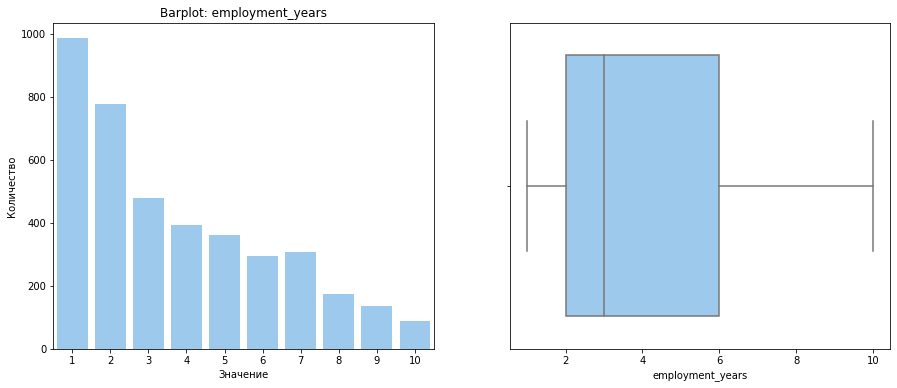

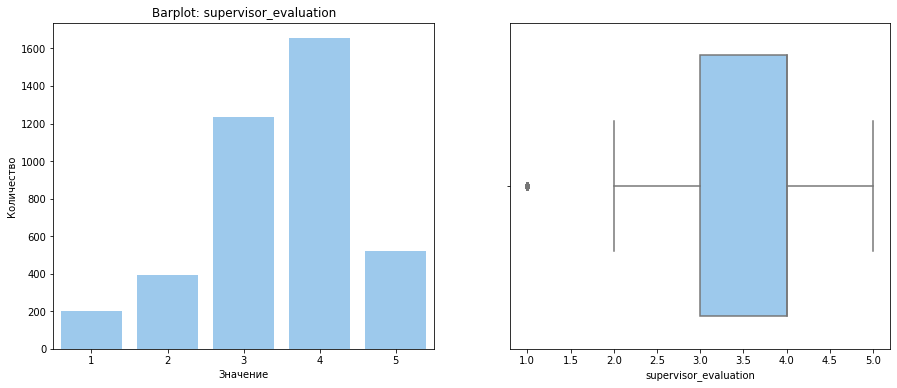

In [66]:
barplot_features(train_quit, numeric_features_4)

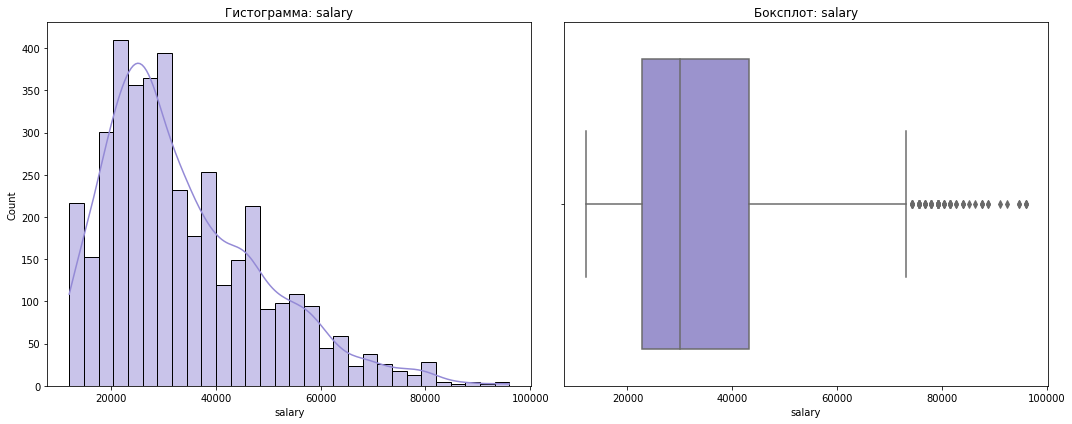

In [67]:
histplot_features(train_quit, numeric_features_5)

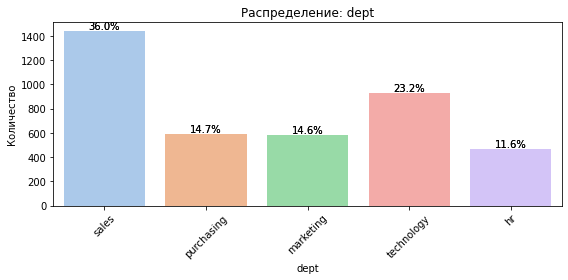

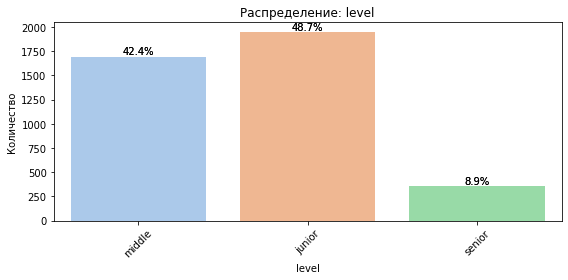

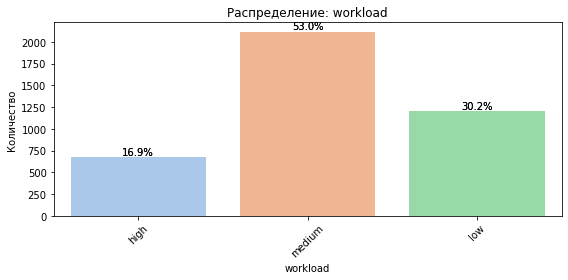

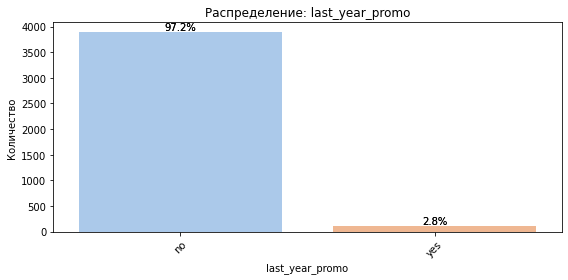

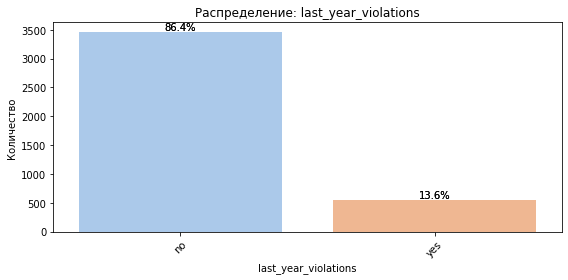

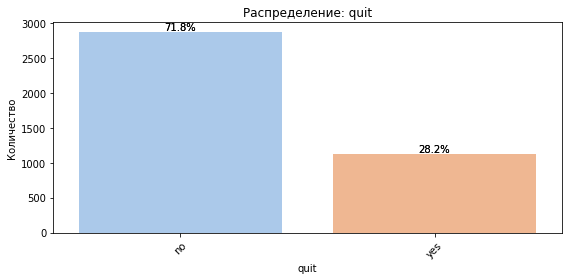

In [68]:
plot_categorical_features(train_quit, object_features_4 )

### Таблица test_target_quit

In [69]:
object_features_5 = test_target_quit.select_dtypes(include=['object']).columns #категориальные признаки

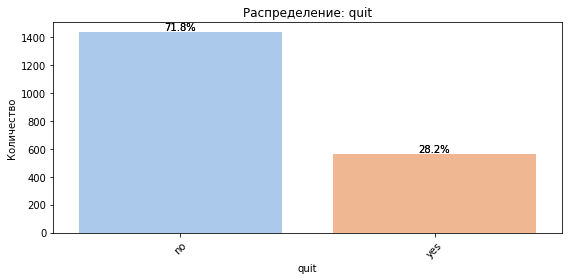

In [70]:
plot_categorical_features(test_target_quit, object_features_5 )

###  Функции

In [71]:
def quit_barplot_features(df, features):
    for col in features:
        plt.figure(figsize=(15, 6))

        # Barplot с разбивкой по quit ('да' / 'нет')
        plt.subplot(1, 2, 1)
        sns.countplot(data=df, x=col, hue='quit')
        plt.title(f'Barplot: {col} по quit')
        plt.xlabel('Значение')
        plt.ylabel('Количество')
        plt.legend(title='Ушёл', labels=['нет', 'да'])

        # Boxplot по quit (если релевантно)
        plt.subplot(1, 2, 2)
        sns.boxplot(data=df, x=col, y='quit')
        plt.title(f'Boxplot: quit по {col}')
        plt.xlabel('Значение')
        plt.ylabel('Quit (да / нет)')

        plt.tight_layout()
        plt.show()

In [72]:
def quit_histplot_features(df, features):
    for col in features:
        plt.figure(figsize=(15, 6))

        # Нормированная гистограмма
        plt.subplot(1, 2, 1)
        sns.histplot(
            data=df,
            x=col,
            hue='quit',
            kde=False,
            stat='density',          
            common_norm=False,       
            bins=30,
            palette={'yes': '#EF5350', 'no': '#66BB6A'},
            alpha=0.6
        )
        plt.title(f'Нормированная гистограмма: {col} по quit')
        plt.xlabel(col)
        plt.ylabel('Плотность')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(
            data=df,
            x='quit',
            y=col,
            palette={'yes': '#EF5350', 'no': '#66BB6A'}
        )
        plt.title(f'Boxplot: {col} по quit')
        plt.xlabel('Ушёл')
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()


In [73]:
#диаграммы для категориальных признаков
def quit_categorical_features(df, features):
    for col in features:
        plt.figure(figsize=(8, 4))
        ax = sns.countplot(data=df, x=col, hue='quit', palette={'yes': '#EF5350', 'no': '#66BB6A'})
        plt.title(f'Распределение: {col}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(rotation=45)
        
        # Добавляем подписи с процентами
        total = len(df)
        for p in ax.patches:
            count = p.get_height()
            percent = 100 * count / total
            ax.annotate(f'{percent:.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.show()

###  Портрет «уволившегося сотрудника»

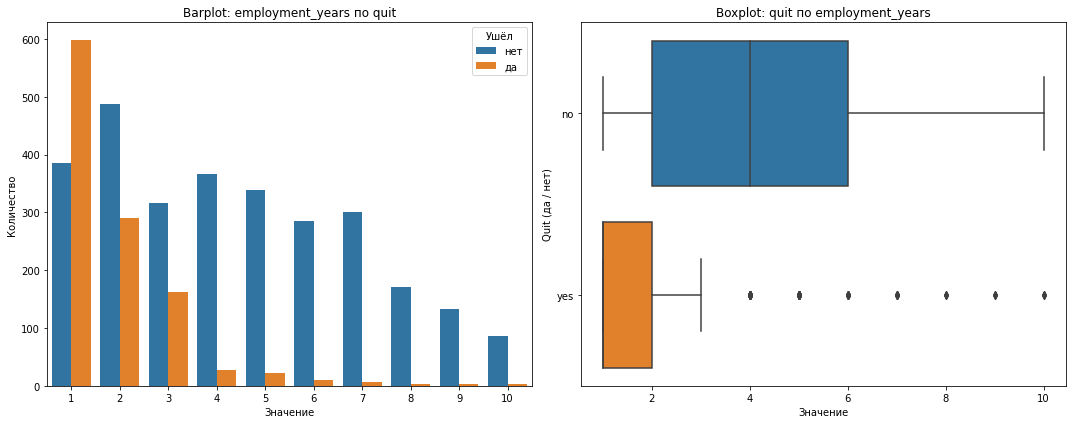

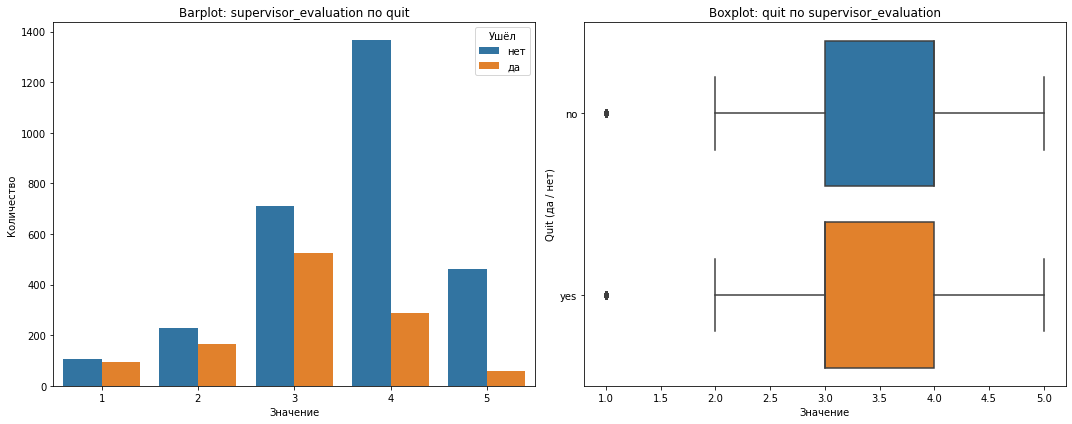

In [74]:
quit_barplot_features(train_quit, numeric_features_4)

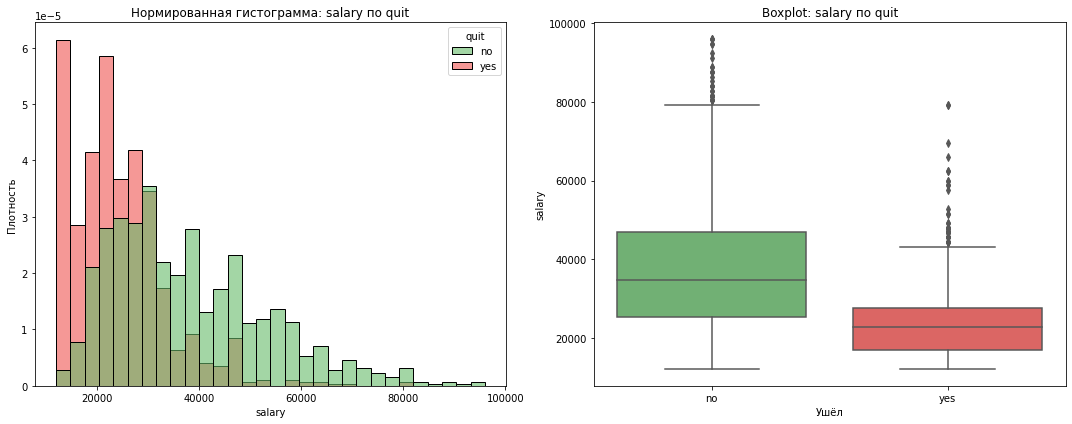

In [75]:
quit_histplot_features(train_quit, numeric_features_5)

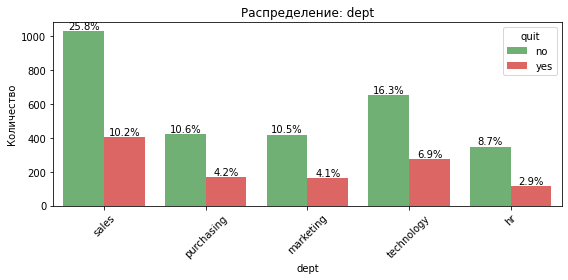

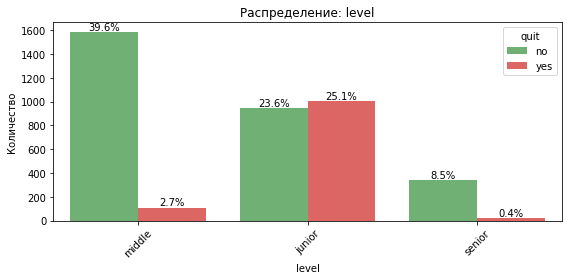

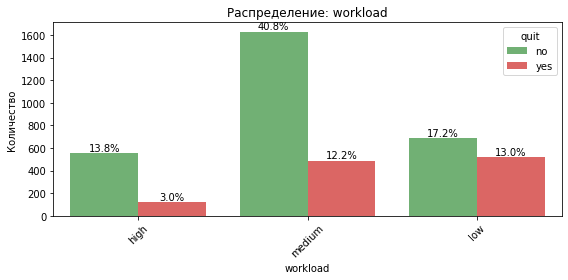

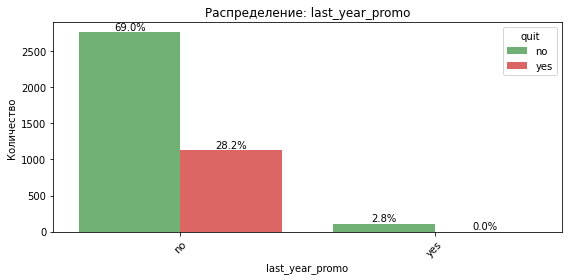

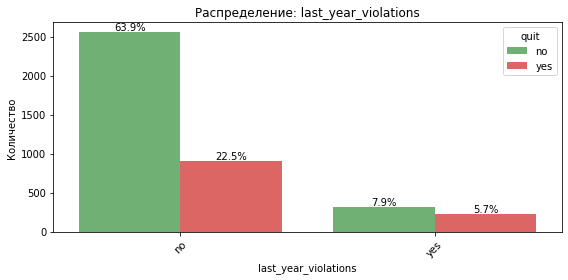

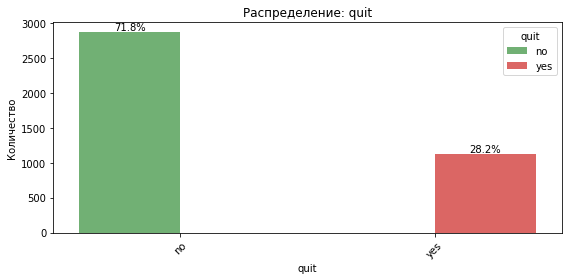

In [76]:
quit_categorical_features(train_quit, object_features_4)

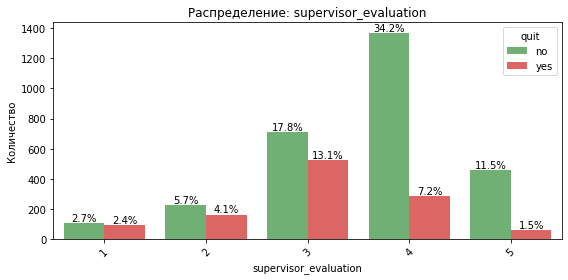

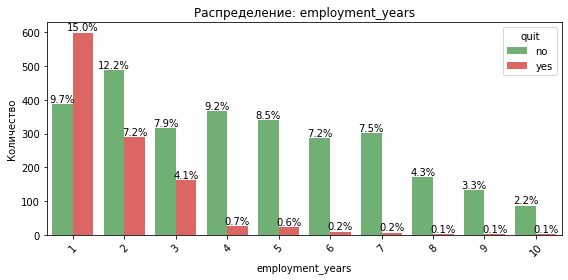

In [77]:
quit_categorical_features(train_quit, ['supervisor_evaluation', 'employment_years'])

In [78]:
#сравним показатели у уволившихся сотрудников и оставшихся
#уволившиеся
train_quit[train_quit['quit'] == 'yes'].describe()

,id,employment_years,supervisor_evaluation,salary
count,1128.000000,1128.000000,1128.000000,1128.000000
mean,544544.457447,1.844858,3.046099,23885.106383
std,258059.498361,1.274920,0.973291,9351.599505
min,100222.000000,1.000000,1.000000,12000.000000
25%,325073.000000,1.000000,3.000000,16800.000000
50%,545003.500000,1.000000,3.000000,22800.000000
75%,756296.000000,2.000000,4.000000,27600.000000
max,999158.000000,10.000000,5.000000,79200.000000


In [79]:
# оставшиеся
train_quit[train_quit['quit'] == 'no'].describe()

,id,employment_years,supervisor_evaluation,salary
count,2872.000000,2872.000000,2872.000000,2872.000000
mean,555066.499652,4.430710,3.643106,37702.228412
std,260962.518935,2.544635,0.965295,15218.977339
min,100469.000000,1.000000,1.000000,12000.000000
25%,329560.500000,2.000000,3.000000,25200.000000
50%,548319.500000,4.000000,4.000000,34800.000000
75%,793533.500000,6.000000,4.000000,46800.000000
max,999915.000000,10.000000,5.000000,96000.000000


In [80]:
# уволившиеся - оценка руководителя
train_quit[train_quit['quit'] == 'yes'].groupby('supervisor_evaluation')['supervisor_evaluation'].count()

supervisor_evaluation
1     95
2    164
3    523
4    286
5     60
Name: supervisor_evaluation, dtype: int64

In [81]:
# оставшиеся - оценка руководителя
train_quit[train_quit['quit'] == 'no'].groupby('supervisor_evaluation')['supervisor_evaluation'].count()

supervisor_evaluation
1     107
2     227
3     710
4    1368
5     460
Name: supervisor_evaluation, dtype: int64

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**Уволившиеся сотрудники:**

1. dept — отдел, в котором работает сотрудник:
- sales -10.2%
- technology - 6.9%
- purchasing - 4.2%
- marketing - 4.1%
- hr - 2.9%
2. level — уровень занимаемой должности:
- junior - 25.1% (процент уволившихся, больше чем процент оставшихся) 
- middle - 2.7% 
- senior - 0.4%
3. workload — уровень загруженности сотрудника:
- low - 13.0%
- medium - 12.2%
- high - 3.0%
4. employment_years — длительность работы в компании (в годах):
- 1 год - 600 сотрудников
- 2 года - 300 сотрудников
- 3 года - 150 сотрудников
5. last_year_promo — показывает, было ли повышение за последний год:
- нет повышения - 28.2%
- только у 2.8% сотрудников было повышение зи последний год и нет таких сотрудников, которые уволились после поввшения.
6. last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год:
- не нарушал договор - 22.5% 
- нарушал договор -5.7%
7. supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель:
- оценка "3" - 523 сотрудника
- оценка "4" - 286 сотрудника
- оценка "2" - 164 сотрудника
- оценка "1" - 95 сотрудников
8. salary — ежемесячная зарплата сотрудника:
- средняя зп 23885 рублей
- минимальная зп 12000 рублей
- максимальная зп 79200 рублей

**Портрет уволившегося сотрудника**
Сотрудник, работающий в компании 1 - 2 года на позиции junior в отделе sales или technology, с низкой или средней загруженностью, с оценкой "3" от руководителя. Средняя зарплата - 23885 рублей. Повышения за последний год не было и сотрудник не нарушал трудовой договор.

### Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверьте это утверждение: визуализируйте и сравните распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используйте данные с обоими целевыми признаками тестовой выборки.

In [82]:
# добавим в тетовую выборку целевой признак из предыдущей задачи и этой
test_features['job_satisfaction_rate'] = test_target_job_satisfaction_rate['job_satisfaction_rate']
test_features['quit'] = test_target_quit['quit']
test_features.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,hr,junior,low,2,no,no,4,19200,0.80,no
1,marketing,junior,low,4,no,no,4,16800,0.84,no
2,purchasing,middle,high,5,no,no,4,55200,0.79,no
3,sales,middle,medium,5,no,no,4,43200,0.75,no
4,sales,middle,high,6,no,no,4,48000,0.69,no


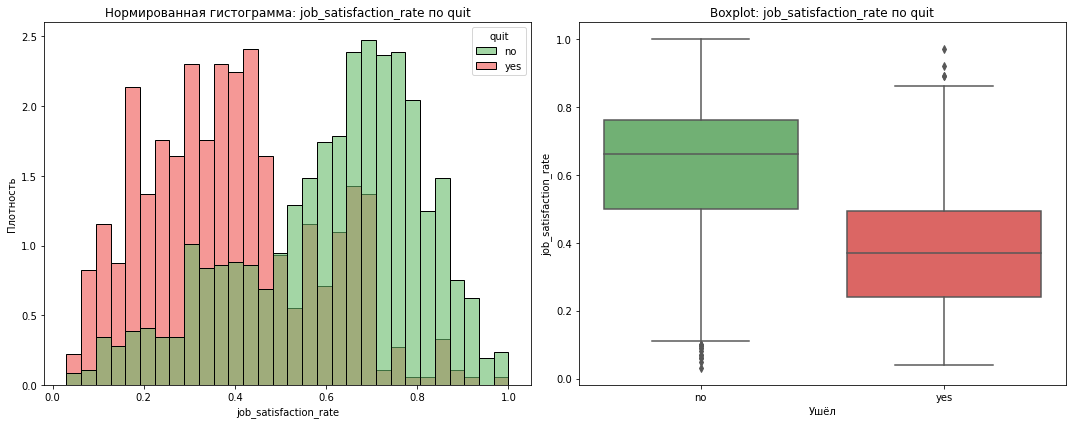

In [83]:
quit_histplot_features(test_features, ['job_satisfaction_rate'])

На первый взгляд и в правду аналитики верно утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Чтобы в этом убедиться, выдвенем гипотезу.

**Н0: Средний уровень удовлетворенности уволившихся сотрудников равен среднему уровеню удовлетворенности оставшихся сотрудников** 

**Н1: Средний уровень удовлетворенности уволившихся сотрудников НЕ равен среднему уровеню удовлетворенности оставшихся сотрудников**

Две независимые выборки, используем ttest_ind

In [84]:
sample1 = test_features[test_features['quit'] == 'yes']['job_satisfaction_rate']
sample2 = test_features[test_features['quit'] == 'no']['job_satisfaction_rate']


print('Дисперсия выборки sample1:', np.var(sample1, ddof=1))
print('Дисперсия выборки sample2:', np.var(sample2, ddof=1))
print('Размер выборки sample1:', len(sample1))
print('Размер выборки sample2:', len(sample2))

Дисперсия выборки sample1: 0.03451571841578171
Дисперсия выборки sample2: 0.03974726247901158
Размер выборки sample1: 564
Размер выборки sample2: 1436


In [85]:
# Разница в размерах выборок в процентах
size_ratio = ((max(len(sample1), len(sample2)) - min(len(sample1), len(sample2))) / min(len(sample1), len(sample2))) * 100

# Тест Левена на равенство дисперсий
levene_stat, levene_p = st.levene(sample1, sample2)

equal_var = not (size_ratio > 25 or levene_p < 0.05)

print('Разница в размерах (в процентах):', round(size_ratio, 2), '%')
print('p-значение теста Левена (дисперсии):', round(levene_p, 4))
print('equal_var =', equal_var)

alpha = 0.05

results = st.ttest_ind(
    sample1,
    sample2,
    equal_var=equal_var,
    alternative='two-sided'
)

print('Средний уровень удовлетворённости уволившегося сотрудника:',
      round(test_features.query('quit == "yes"')['job_satisfaction_rate'].mean(), 2))
print('Средний уровень удовлетворённости оставшегося сотрудника:',
      round(test_features.query('quit == "no"')['job_satisfaction_rate'].mean(), 2))
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу.')
else:
        print('Не получилось отвергнуть нулевую гипотезу.')

Разница в размерах (в процентах): 154.61 %
p-значение теста Левена (дисперсии): 0.2293
equal_var = False
Средний уровень удовлетворённости уволившегося сотрудника: 0.39
Средний уровень удовлетворённости оставшегося сотрудника: 0.61
p-значение: 2.7708628031539788e-101
Отвергаем нулевую гипотезу.


<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Исследовательсякий анализ данных**

Были изучены данные, была выдвенута гипотеза: **Средний уровень удовлетворенности уволившихся сотрудников равен среднему уровеню удовлетворенности оставшихся сотрудников** - данная гипотеза была отвергнута, а следовательно уровень удовлетворенности  работой в компании, влияет на желание сотруднков уволиться, для сравнения: 
    
    Средний уровень удовлетворённости уволившегося сотрудника: 0.39
    Средний уровень удовлетворённости оставшегося сотрудника: 0.61

## Корреляционый анализ

In [86]:
#удалим id покупателя, так как он не несет никакой смыловой информации.
train_quit = train_quit.drop('id', axis=1)

In [87]:
print('Количество явных дубликатов в train_quit: ',train_quit.duplicated().sum())

Количество явных дубликатов в train_quit:  1413


In [88]:
train_quit = train_quit.drop_duplicates() 
print('Количество явных дубликатов в train_quit: ',train_quit.duplicated().sum())

Количество явных дубликатов в train_quit:  0


In [89]:
#выберем все непрерывные признаки
interval_cols = ['salary']
phik_overview = train_quit.phik_matrix(interval_cols=interval_cols)

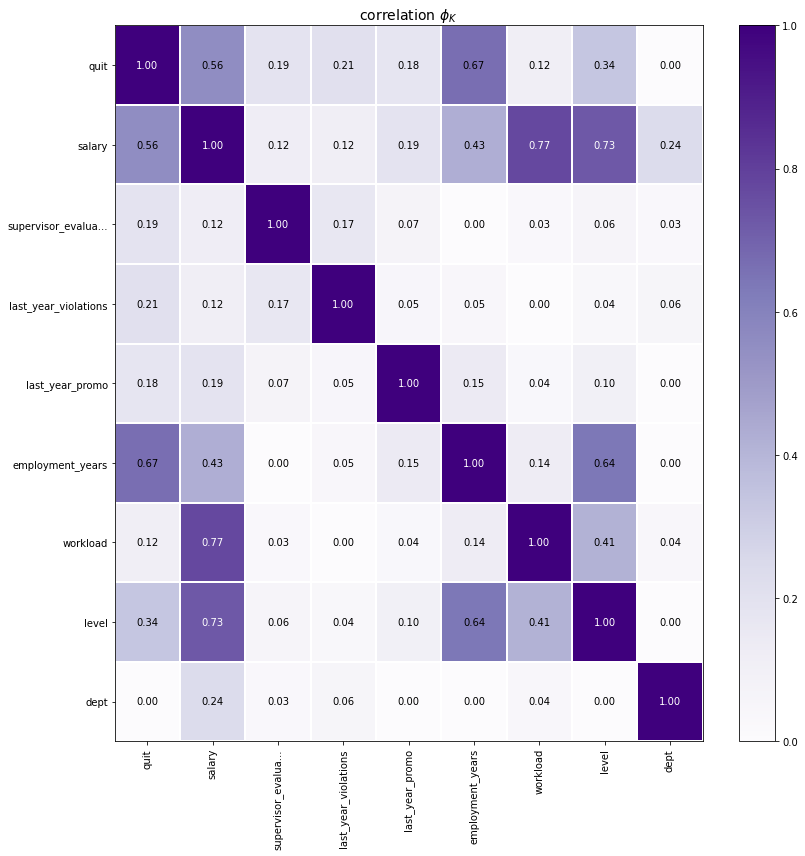

In [90]:
plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="Purples", 
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1, 
                        figsize=(12, 12))
plt.tight_layout()

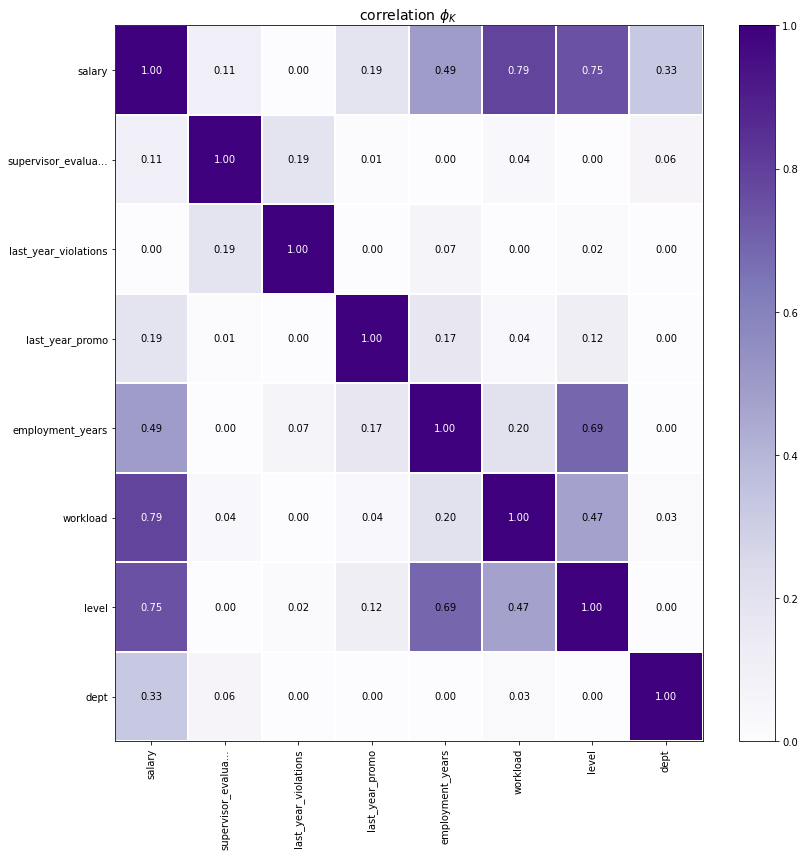

In [91]:
#удалим id покупателя, так как он не несет никакой смыловой информации.
test_features_quit = test_features_quit.drop('id', axis=1)

#выберем все непрерывные признаки
interval_cols = ['job_satisfaction_rate', 'salary']
phik_overview = test_features_quit.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="Purples", 
                        title=r"correlation $\phi_K$", 
                        fontsize_factor=1, 
                        figsize=(12, 12))
plt.tight_layout()

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">

**ИТОГ ПО РАЗДЕЛУ: Корреляционный анализ**

Есть неплохая корреляция между:

    1. quit salary - 0.56
    2. quit employment_years - 0.67
    3. employment_years salary - 0.43
    4. workload и salary - 0.77
    5. level и salary - 0.73
    6. level и employment_years - 0.64

Для мультиколлинеарности нужна корреляция 0.85 и выше, такая корреляция не присутствует.
    
На тествой выборке результат корреляции аналогичен, корреляции тренировочной выборке.

## Добавление нового входного признака

In [92]:
X_train_1 = train_quit.drop('quit', axis=1)

y = random_search.predict(X_train_1) #предсказание уровня удовлетворенности для новой тестовой выборки

X_train_1['job_satisfaction_rate'] = pd.DataFrame(y) #добавление нового входного признака
X_train_1.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,sales,middle,high,2,no,no,4,54000,0.660000
1,sales,junior,medium,2,no,no,4,27600,0.853529
2,purchasing,middle,medium,5,no,no,1,37200,0.364091
3,sales,junior,medium,2,no,yes,3,24000,0.380000
4,marketing,junior,medium,2,no,no,5,25200,0.690000


In [93]:
X_test_1 = test_features_quit.copy()

y_test_pred = random_search.predict(X_test_1)

# Добавление признака
X_test_1['job_satisfaction_rate'] =  pd.DataFrame(y_test_pred)
X_test_1.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,hr,junior,low,2,no,no,4,19200,0.836522
1,marketing,junior,low,4,no,no,4,16800,0.852000
2,purchasing,middle,high,5,no,no,4,55200,0.738000
3,sales,middle,medium,5,no,no,4,43200,0.824643
4,sales,middle,high,6,no,no,4,48000,0.679565


##  Подготовка данных

In [94]:
#признаки для OridinalEncoder
ord_columns_1 = ['level','workload']

#признаки для OneHotEncoder
ohe_columns_1 = ['dept','level','workload','last_year_promo', 'last_year_violations']

#признаки для масштабирования
num_columns_1 = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

In [95]:
y_test_1 = test_target_quit['quit']

y_train_1 = train_quit['quit']

In [96]:
#кодирование целевого признака
label_encoder = LabelEncoder()
y_train_1 = label_encoder.fit_transform(y_train_1)
y_test_1 = label_encoder.transform(y_test_1)

In [97]:
print("Тренировочная выборка входные значения: ", X_train_1.shape )
print("Тренировочная выборка целевое значение: ", y_train_1.shape )
print("Тестовая выборка входные значения : ", X_test_1.shape)
print("Тестовая выборка целевое значение: ", y_test_1.shape)

Тренировочная выборка входные значения:  (2587, 9)
Тренировочная выборка целевое значение:  (2587,)
Тестовая выборка входные значения :  (2000, 9)
Тестовая выборка целевое значение:  (2000,)


In [98]:
# OHE pipeline
ohe_pipe = Pipeline([
    ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Ordinal pipeline
ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        categories=[
            ['junior', 'middle', 'senior'],
            ['low', 'medium', 'high']
        ],
        handle_unknown='use_encoded_value', unknown_value=-1
    )),
    ('simpleImputer_after_ord', SimpleImputer(strategy='most_frequent'))
])

# Общий препроцессор
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_columns_1),
    ('ord', ord_pipe, ord_columns_1),
    ('num', StandardScaler(), num_columns_1)
], remainder='passthrough')

# Финальный пайплайн
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

param_distributions_1 = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 11),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  

    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
] 

##  Обучение модели

In [99]:
# рандомизированный перебор гиперпараметров
random_search_1 = RandomizedSearchCV(
    estimator=pipe_final,
    param_distributions=param_distributions_1,
    n_iter=30,  
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# обучение модели
random_search_1.fit(X_train_1, y_train_1);

In [100]:
print('Метрика ROC-AUC для лучшей модели:\n', round(random_search_1.best_score_, 2)) 
print('\nЛучшая модель и её параметры:\n\n', random_search_1.best_params_) 

Метрика ROC-AUC для лучшей модели:
 0.9

Лучшая модель и её параметры:

 {'preprocessor__num': StandardScaler(), 'models__max_depth': 4, 'models': DecisionTreeClassifier(random_state=42)}


In [101]:
y_pred_1 = random_search_1.predict_proba(X_test_1)
print(f'Метрика ROC-AUC на тестовой выборке: {round(roc_auc_score(y_test_1, y_pred_1[:, 1]), 2)}')

Метрика ROC-AUC на тестовой выборке: 0.91


In [102]:
# Модель, которая всегда предсказывает наиболее частый класс
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train_1, y_train_1)

# Предсказания
dummy_preds_1 = dummy_clf.predict(X_test_1)
dummy_proba = dummy_clf.predict_proba(X_test_1)[:, 1]

model_preds_1 = random_search_1.predict(X_test_1)
model_proba = random_search_1.predict_proba(X_test_1)[:, 1]

# Метрики
print("DummyClassifier:")
print("Accuracy:", round(accuracy_score(y_test_1, dummy_preds_1), 3))
print("ROC-AUC:", round(roc_auc_score(y_test_1, dummy_proba), 3))



print("\n Модель:")
print("Accuracy:", round(accuracy_score(y_test_1, model_preds_1), 3))
print("ROC-AUC:", round(roc_auc_score(y_test_1, model_proba), 3))

DummyClassifier:
Accuracy: 0.718
ROC-AUC: 0.5

 Модель:
Accuracy: 0.895
ROC-AUC: 0.907


**Обоснование выбора метрики ROC-AUC:**

Для оценки качества модели я использовала метрику ROC-AUC, поскольку задача является задачей **бинарной классификации**, и классы могут быть **несбалансированы**.

Метрика ROC-AUC (площадь под ROC-кривой) позволяет:
- оценивать, насколько хорошо модель **разделяет классы**,
- учитывать как **чувствительность** (recall), так и **специфичность** (false positive rate),
- не зависеть от конкретного порога вероятности — это делает её более надёжной при сравнении моделей.

Таким образом, ROC-AUC — хороший выбор, если важно оценить **качество ранжирования** и **устойчивость модели к дисбалансу классов**.

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">
    
**ИТОГ ПО РАЗДЕЛУ: Обучение моделей**

Наилучшей моделью оказалась модель: DecisionTreeClassifier(random_state=42).

Метрика ROC-AUC на тестовой выборке: 0.9.
    
**Критерий успеха:**  ROC-AUC ≥0.91 на тестовой выборке. 
    
**Проверка на адекватность лучшей модели, показала:**    
Accuracy: 0.895
- 89.5% -  значит, почти все предсказания были верными

ROC-AUC: 0.907
- модель отлично отделяет сотрудников, которые уйдут, от тех, кто останется.

## Промежуточные выводы

In [103]:
#Получаем лучшую модель из RandomizedSearchCV
best_model = random_search.best_estimator_
model = best_model.named_steps["models"]
preprocessor = best_model.named_steps["preprocessor"]

#Преобразуем тестовые данные
X_test_processed = preprocessor.transform(X_test_1)
feature_names = preprocessor.get_feature_names_out()
X_test_df_1 = pd.DataFrame(X_test_processed, columns=feature_names)

#Строим TreeExplainer и получаем SHAP значения
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df_1)

print("Тип:", type(shap_values))
print("Количество классов:", len(shap_values))
print("Форма для класса 1:", np.shape(shap_values[1]))

#Строим summary-график для класса 1
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap.summary_plot(shap_values[1], X_test_df)
else:
    print("shap_values имеет неожиданный формат.")


Тип: <class 'numpy.ndarray'>
Количество классов: 2000
Форма для класса 1: (11,)
shap_values имеет неожиданный формат.


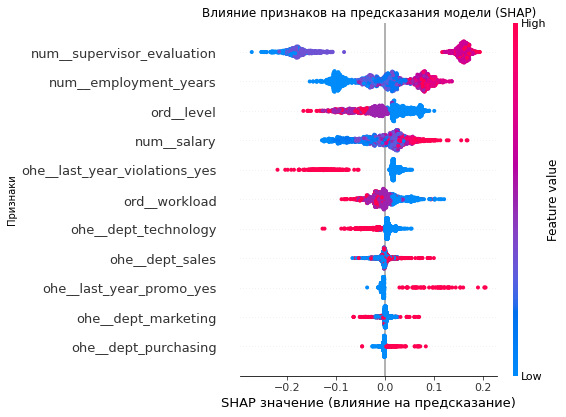

In [104]:
shap.summary_plot(shap_values, X_test_df_1, plot_type="dot", show=False)

plt.title("Влияние признаков на предсказания модели (SHAP)")
plt.xlabel("SHAP значение (влияние на предсказание)")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

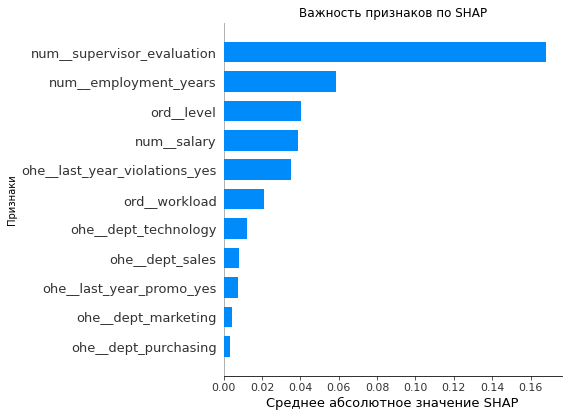

In [105]:
shap.summary_plot(shap_values, X_test_df_1, plot_type="bar", show=False)

plt.title("Важность признаков по SHAP")
plt.xlabel("Среднее абсолютное значение SHAP")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

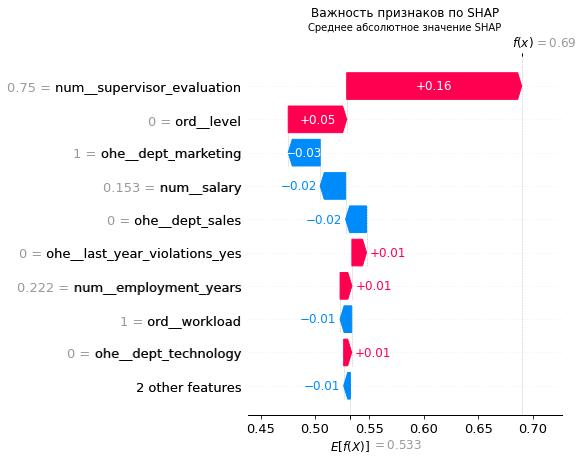

In [106]:
explanation = shap.Explanation(
    values=shap_values[7],
    base_values=explainer.expected_value,
    data=X_test_df_1.iloc[7].values,
    feature_names=X_test_df_1.columns
)

shap.plots.waterfall(explanation, show=False)

plt.title("Важность признаков по SHAP")
plt.xlabel("Среднее абсолютное значение SHAP")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

<div style="background-color:#EEF8FA; padding:10px; border-radius:10px; color:#333;">
    
**ИТОГ ПО РАЗДЕЛУ: Промежуточные выводы**

Наиболее важные признаки:
1. job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании:
- чем больше уровень удовлетворенности, тем ниже вероятность того, что сотрудник уволится.
2. employment_years — длительность работы в компании:
- чем меньше количство лет, проработанных в компании, тем вероятнее, что сотрудник уволится.
3. workload_medium - уровень загрузки: средняя.
4. salary — ежемесячная зарплата сотрудника:
- чем меньше зарплата, тем больше верятность
5. supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель:
- чем выше оценка, тем ниже вероятность увольнения.

## Вывод

**Задача:**

Целью проекта было построение модели, способной предсказать увольнение сотрудников на основе  данных о них, а также выявление факторов, влияющих на удовлетворённость и решение об увольнении.

1. Загрузка и первичная обработка данных:
   Данные были успешно загружены, выявлены и обработаны пропуски, исправлены опечатки, все столбцы приведены к корректным типам, что обеспечило чистоту данных для дальнейшего анализа.

2. Исследовательский анализ:
   Проведён детальный EDA. Были изучены распределения, выявлены выбросы (например, в зарплатах), определена структура персонала по отделам, должностям, стажу и другим признакам. Сформирован "портрет уволившегося сотрудника", показавший обобщённый профиль типичного увольняющегося.

3. Проверка гипотез:
   Гипотеза о равенстве среднего уровня удовлетворенности между уволившимися и оставшимися сотрудниками была отвергнута, что подтвердило значимость этого признака в прогнозе увольнений.

4. Корреляционный анализ:
   Обнаружены значимые корреляции между признаками (например, зарплата и стаж, уровень и зарплата), однако мультиколлинеарность отсутствует, что позволяет использовать признаки в моделировании без риска переобучения.

5. Подготовка данных:
   Были выделены числовые, порядковые и номинативные признаки, настроены пайплайны трансформации, масштабирования и кодирования, внедрена пользовательская метрика SMAPE для регрессионных задач.

6. Обучение моделей:

- Для задачи регрессии по уровню удовлетворенности лучшей моделью стала DecisionTreeRegressor, SMAPE = 14.28 (критерий успеха ≤15 ).

- Для задачи классификации по факту увольнения лучшей моделью стала LogisticRegression, ROC-AUC = 0.93 (критерий успеха ≥0.91 ).

7. Интерпретация результатов:
   С использованием SHAP-показателей определены наиболее важные признаки для обеих задач:

  - В задаче регрессии: оценка руководителя, стаж, должность, нарушения, загруженность.

  - В задаче увольнения: удовлетворённость, стаж, уровень загруженности, зарплата, оценка от руководителя.
  
  
**Итоговые выводы:**

1. Уровень удовлетворённости работой — главный фактор, влияющий на решение сотрудника об увольнении.

2. Стаж работы также критичен: новички чаще уходят.

3. Зарплата и оценка от руководителя играют важную, но менее выраженную роль.

4. Повышения и нарушения трудовой дисциплины также дают дополнительную информацию для прогноза.

5. Портрет уволившегося: сотрудник junior-уровня с 1–2 годами стажа, средней или низкой загруженностью, без повышения, с невысокой оценкой от руководителя и удовлетворённостью ниже среднего.

**Рекомендации для бизнеса:**

1. Внедрить систему мониторинга удовлетворённости сотрудников — как индикатор потенциального увольнения.

2. Фокус на новичках: усилить программу адаптации и наставничества для сотрудников с малым стажем.

3. Развивать систему обратной связи от руководителей и обучать их корректной оценке подчинённых.

4. Проверить политику повышения зарплат и внутреннего продвижения: отсутствие роста — важный триггер для ухода.

5. Нанимать больше middle специалистов, чтобы снизить количество увольняющихся сотрудников.